## Phase 4: Modeling

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os

X_tr = pd.read_parquet("../data/features_train.parquet")
X_te = pd.read_parquet("../data/features_test.parquet")
y_tr = pd.read_parquet("../data/labels_train.parquet")["lapsed"]
y_te = pd.read_parquet("../data/labels_test.parquet")["lapsed"]

# Align labels to feature row order - indexes must match exactly
y_tr = y_tr.reindex(X_tr.index)
y_te = y_te.reindex(X_te.index)

print(X_tr.shape, X_te.shape)
print("missing:", X_tr.isna().sum().sum(), X_te.isna().sum().sum())

(5045, 13) (5160, 13)
missing: 0 0


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

cv = StratifiedKFold(5, shuffle=True, random_state=42)
SCORING = ["accuracy", "precision", "recall", "roc_auc", "average_precision"]

# All features are numeric, so preprocessing is just impute + scale.
# Trees don't need the scaler but it's harmless
prep = Pipeline([("impute", SimpleImputer(strategy="median")),
                 ("scale", StandardScaler())])

models = {
    "Dummy":         DummyClassifier(strategy="most_frequent"),
    "Recency only":  None,   # filled in below
    "LogisticReg":   LogisticRegression(max_iter=2000),
    "RandomForest":  RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "HistGradBoost": HistGradientBoostingClassifier(random_state=42),
}

In [4]:
# A one-feature baseline. If the full model can't beat recency alone,
# the other twelve features arent' earning their place.
rows = []

r = cross_validate(Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000))]),
                   X_tr[["recency_days"]], y_tr, cv=cv, scoring=SCORING, n_jobs=-1)
rows.append({"model": "Recency only", **{m: r["test_" + m].mean() for m in SCORING},
             "roc_auc_std": r["test_roc_auc"].std()})

for name, clf in models.items():
    if clf is None:
        continue
    r = cross_validate(Pipeline([("prep", prep), ("clf", clf)]),
                       X_tr, y_tr, cv=cv, scoring=SCORING, n_jobs=-1)
    rows.append({"model": name, **{m: r["test_" + m].mean() for m in SCORING},
                 "roc_auc_std": r["test_roc_auc"].std()})

pd.DataFrame(rows).set_index("model").round(4).sort_values("roc_auc", ascending=False)

,accuracy,precision,recall,roc_auc,average_precision,roc_auc_std
model,,,,,,
RandomForest,0.8032,0.8020,0.8080,0.8851,0.8805,0.0059
HistGradBoost,0.7968,0.7974,0.7989,0.8825,0.8835,0.0045
LogisticReg,0.7984,0.7725,0.8490,0.8800,0.8672,0.0045
Recency only,0.6961,0.7231,0.6423,0.7572,0.7327,0.0050
Dummy,0.5027,0.5027,1.0000,0.5000,0.5027,0.0000


---
## Phase 5: Tune

In [6]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipe = Pipeline([("prep", prep),
                    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))])

rf_dist = {
    "clf__n_estimators":      [300, 600],
    "clf__max_depth":         [None, 8, 12, 20],
    "clf__min_samples_leaf":  [1, 5, 20, 50],
    "clf__max_features":      ["sqrt", 0.5, None],
}

rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=20, scoring="roc_auc",
                               cv=cv, n_jobs=-1, random_state=42)
rf_search.fit(X_tr, y_tr)
print("RF tuned:", round(rf_search.best_score_, 4), "| untuned: 0.8851")
print(rf_search.best_params_)

RF tuned: 0.8925 | untuned: 0.8851
{'clf__n_estimators': 300, 'clf__min_samples_leaf': 20, 'clf__max_features': 0.5, 'clf__max_depth': None}


In [7]:
lr_pipe = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000))])
lr_grid = {"clf__C": [0.01, 0.1, 1, 10, 100]}

from sklearn.model_selection import GridSearchCV
lr_search = GridSearchCV(lr_pipe, lr_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
lr_search.fit(X_tr, y_tr)
print("LR tuned:", round(lr_search.best_score_, 4), "| untuned: 0.8800")
print(lr_search.best_params_)

LR tuned: 0.8802 | untuned: 0.8800
{'clf__C': 100}


---
## Phase 6: Final evaluation on the later anchor

In [9]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix, roc_curve)

final = rf_search.best_estimator_

proba_te = final.predict_proba(X_te)[:, 1]

print("TEST  ROC-AUC:", round(roc_auc_score(y_te, proba_te), 4))
print("TRIAN ROC-AUC:", round(rf_search.best_score_, 4))
print()
print(classification_report(y_te, (proba_te >= 0.5).astype(int),
                            target_names=["Stayed", "Lapsed"], digits=3))

TEST  ROC-AUC: 0.8959
TRIAN ROC-AUC: 0.8925

              precision    recall  f1-score   support

      Stayed      0.822     0.797     0.809      2523
      Lapsed      0.811     0.835     0.823      2637

    accuracy                          0.816      5160
   macro avg      0.817     0.816     0.816      5160
weighted avg      0.817     0.816     0.816      5160



         feature  auc_drop
   n_active_days    0.1762
    recency_days    0.0120
  per_active_day    0.0099
     trend_30_90    0.0022
     tenure_days    0.0017
lifetime_ratings    0.0013
            n_90    0.0010
             n_7    0.0007
            n_30    0.0004
        n_movies    0.0002
           n_365    0.0001
      rating_std   -0.0002
     rating_mean   -0.0004


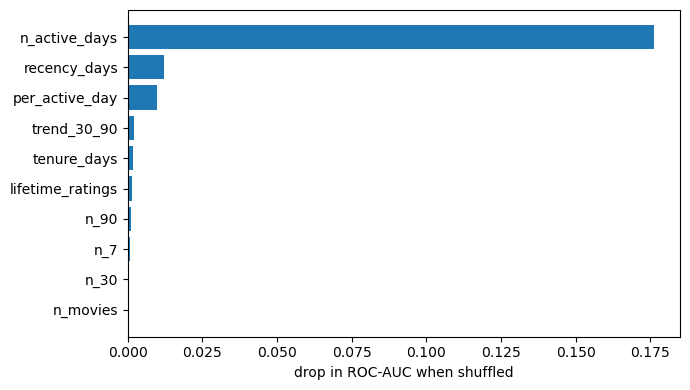

In [10]:
# Feature importance, model-agnostic
from sklearn.inspection import permutation_importance

pi = permutation_importance(final, X_te, y_te, scoring="roc_auc",
                            n_repeats=10, random_state=42, n_jobs=-1)

imp = (pd.DataFrame({"feature": X_te.columns, "auc_drop": pi.importances_mean}).
       sort_values("auc_drop", ascending=False))
print(imp.round(4).to_string(index=False))

top = imp.head(10).iloc[::-1]
plt.figure(figsize=(7, 4))
plt.barh(top.feature, top.auc_drop)
plt.xlabel("drop in ROC-AUC when shuffled")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150)
plt.show()

In [11]:
# Drop-column check: retrain without a feature and see what actually changes
from sklearn.base import clone

base = roc_auc_score(y_te, final.predict_proba(X_te)[:, 1])
print(f"all features: {base:.4f}")

for col in ["n_active_days", "recency_days", "per_active_day"]:
    m = clone(final).fit(X_tr.drop(columns=[col]), y_tr)
    s = roc_auc_score(y_te, m.predict_proba(X_te.drop(columns=[col]))[:, 1])
    print(f"without {col:16s} {s:.4f}   ({s - base:+.4f})")

all features: 0.8959
without n_active_days    0.8921   (-0.0038)
without recency_days     0.8937   (-0.0022)
without per_active_day   0.8958   (-0.0001)


In [12]:
os.makedirs("../demo", exist_ok=True)

# Save the model with its feature order - the app needs both
joblib.dump({"model": final, "features": list(X_tr.columns)},
            "../models/model.joblib", compress=3)

# Save 300 real test users for the demo to browse
sample = X_te.sample(300, random_state=1).copy()
sample["actual_lapsed"]  = y_te.loc[sample.index]
sample["predicted_risk"] = final.predict_proba(sample[X_tr.columns])[:, 1]
sample.insert(0, "user", [f"U{i:04d}" for i in range(len(sample))])  # anonymise
sample.to_csv("../demo/sample_users.csv", index=False)

print("model: %.1f MB" % (os.path.getsize("../models/model.joblib") / 1e6))
print("sample:", sample.shape)

model: 1.7 MB
sample: (300, 16)
